In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
traindf = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
dtypes = np.unique(traindf.dtypes)

In [3]:
traindf = traindf.select_dtypes(include = dtypes[:-1])

In [4]:
target = traindf.SalePrice
traindf.drop(['Id','SalePrice'],axis = 1,inplace = True)

In [5]:
traindf.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [6]:
mean = np.mean(traindf,axis = 0)
std = np.std(traindf,axis = 0)

<Axes: xlabel='SalePrice', ylabel='Count'>

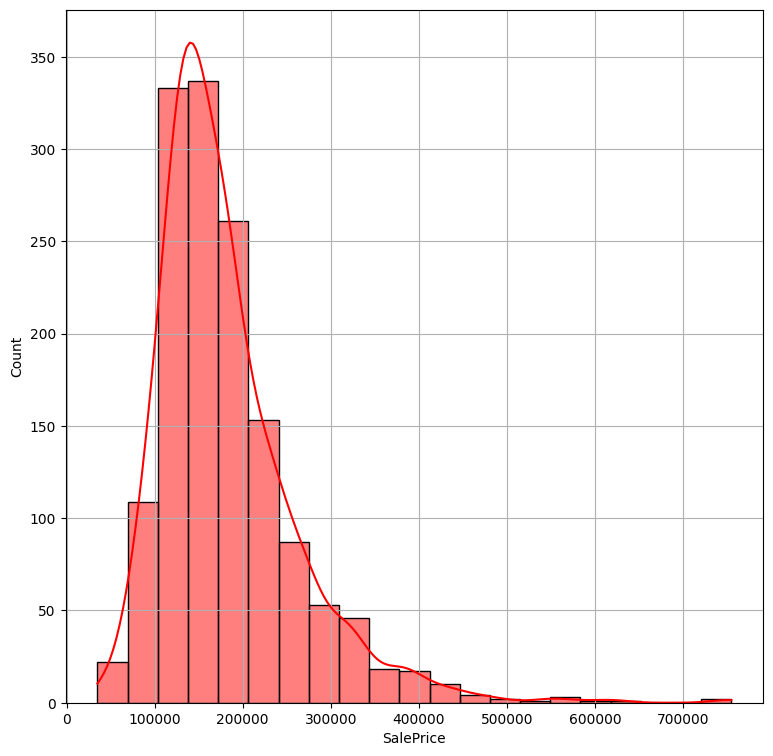

In [7]:
import seaborn as scn
import matplotlib.pyplot as plt
plt.figure(figsize = (9,9))
plt.grid()
scn.histplot(target,kde = True,color = 'red',bins = 21)

In [8]:
for col in traindf.columns:
    mean = np.mean(traindf[col])
    std = np.std(traindf[col])
    mask = np.abs((traindf[col] - mean)/std) < 3.0
    traindf = traindf[mask]
    target = target[mask]

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

tdf,vdf,ttarget,vtarget = train_test_split(traindf,target,test_size = 0.3,shuffle = True)
print(f"validation set {len(vdf)} | training set {len(tdf)}")

model = LinearRegression()
model.fit(tdf,ttarget)
print('Training Completed')
print('*'*100)
print(f"r2_score = {r2_score(vtarget,model.predict(vdf))}")

validation set 228 | training set 532
Training Completed
****************************************************************************************************
r2_score = 0.8583168201797411


In [10]:
r2_score(ttarget,model.predict(tdf))

0.8976819663969956

In [11]:
testdf = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
idx = testdf.Id
testdf.drop('Id',axis =1,inplace = True)
testdf = testdf.loc[:,tdf.columns]

In [12]:
for i,col in enumerate(testdf.columns):
    testdf[col] = testdf[col].fillna(mean)

In [13]:

pred = model.predict(testdf)

submit = pd.DataFrame({'Id' : idx , 'SalePrice' : pred})
print(submit.head())
submit.to_csv('submit.csv',index = False)

     Id      SalePrice
0  1461  138252.904811
1  1462   18500.666540
2  1463  185411.665359
3  1464  201541.425757
4  1465  190158.099927


In [14]:
testdf.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,...,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,57.378341,370.293567,9819.161069,6.078821,5.553804,1971.357779,1983.662783,120.315821,440.278811,53.959414,...,473.820963,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,42.746880,703.430577,4955.517327,1.436812,1.113740,30.390071,21.130467,261.263771,456.960856,183.958113,...,220.664411,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,60.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,50.000000,72.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,351.000000,0.000000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,92.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,172.000000,755.000000,0.000000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,2007.785526,56600.000000,10.000000,9.000000,2010.000000,2010.000000,2007.785526,4010.000000,2007.785526,...,2007.785526,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [15]:

import jax
from jax import numpy as jnp
from jax import jit

class Node:
  def __init__(self,x,y):
    self.params = {'b' : jnp.float32(0),
    'w' : jnp.zeros(x.shape[1])}

  @staticmethod
  @jit
  def loss(params,x,y):
    pred = Node.predict(params,x)
    mse = jnp.mean((pred - y)**2)
    return mse

  @staticmethod
  @jit
  def predict(params,x):
    pred = jnp.dot(x,params['w']) + params['b']
    return pred

  @staticmethod
  @jit
  def grad(params,x,y):
    return jax.grad(Node.loss)(params,x,y)

  @staticmethod
  @jit
  def grad_step(x,y,params):
    param_grad = Node.grad(params,x,y)
    param_grad['w'] = params['w'] -0.001*param_grad['w']
    param_grad['b'] = params['b'] - 0.001*param_grad['b']
    return param_grad

  def fit(self,x,y,epochs = 100):
    for i in range(epochs):
      self.params = Node.grad_step(x,y,self.params)
      # print(f"Epoch {i + 1} | Loss : {Node.loss(self.params,x,y)}")

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
tdf = scaler.fit_transform(tdf)


In [17]:
tmean = np.mean(ttarget)
tstd = np.std(ttarget)

In [18]:
ttarget = (ttarget - tmean)/tstd

In [19]:
model1 = Node(jnp.array(tdf),jnp.array(ttarget))

ERROR:2026-01-19 22:52:46,220:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/usr/local/lib/python3.12/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


In [20]:
model1.fit(jnp.array(tdf),jnp.array(ttarget),epochs = 10000)

In [21]:
vdf = scaler.transform(vdf)
vtarget = (vtarget - tmean)/tstd


In [22]:
r2_score(vtarget,model1.predict(model1.params,jnp.array(vdf)))

0.8584053931754295

In [23]:
r2_score(ttarget,model1.predict(model1.params,jnp.array(tdf)))

0.8976412797476383

In [24]:
testdf = scaler.transform(testdf)

In [25]:
pred = model1.predict(model1.params,jnp.array(testdf))*tstd + tmean

submit = pd.DataFrame({'Id' : idx , 'SalePrice' : pred})
print(submit.head())
submit.to_csv('submit.csv',index = False)

     Id      SalePrice
0  1461  137378.765625
1  1462   15482.031250
2  1463  185213.140625
3  1464  201472.062500
4  1465  190303.640625
